In [1]:
import os
from torchvision import io, utils
from pycocotools.coco import COCO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from pycocotools.cocoeval import COCOeval
from torchvision.datasets import CocoDetection
import torch
from torchvision.transforms.functional import to_tensor
import pytorch_lightning as pl
import json
import pandas as pd

from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# PARAMETERS
NUM_CLASSES = 7 # 7 classes + background
EPOCHS = 100
MODEL_TYPE = "fasterrcnn"
VERSION = "1_puro"
CHECKPOINT = "tb_logs/vitdet/version_2/checkpoints/best-val-loss-v1.ckpt"
EVALUATION_RESULTS_FOLDER = "./evaluation_results"


# Caminhos do dataset
ROOT_DIR = "../../SVRDD_COCO"
TRAIN_DIRECTORY = os.path.join(ROOT_DIR, "train")
VAL_DIRECTORY = os.path.join(ROOT_DIR, "valid")
TEST_DIRECTORY = os.path.join(ROOT_DIR, "test")
ANNOTATION_FILE_NAME = "_annotations.coco.json"
DETECTIONS_PATH = "detections.json"
CLASSES = {
    0: "longitudinal crack",
    1: "transverse crack",
    2: "alligator crack",
    3: "pothole",
    4: "manhole cover",
    5: "longitudinal patch",
    6: "transverse patch",
}

In [3]:
def count_classes(coco_gt):
    # --- Contagem de instâncias ---
    cat_ids = coco_gt.getCatIds()
    cats = [coco_gt.loadCats([i])[0]["name"] for i in cat_ids]
    area_labels = ["small", "medium", "large"]

    counts_dict = {cat: {"small":0, "medium":0, "large":0} for cat in cats}
    ann_ids = coco_gt.getAnnIds()
    anns = coco_gt.loadAnns(ann_ids)

    for ann in anns:
        cat_name = coco_gt.loadCats([ann["category_id"]])[0]["name"]
        area = ann["area"]
        if area < 32**2:
            counts_dict[cat_name]["small"] += 1
        elif area < 96**2:
            counts_dict[cat_name]["medium"] += 1
        else:
            counts_dict[cat_name]["large"] += 1
    return cats, counts_dict


def evaluate_coco(dataset_dir, json_detection_path, excel_path="coco_results.xlsx"):

    GT_ANN_FILE = os.path.join(dataset_dir, ANNOTATION_FILE_NAME)

    # carregar ground truth
    coco_gt = COCO(GT_ANN_FILE)

    # carregar detecções
    coco_dt = coco_gt.loadRes(json_detection_path)

    # rodar avaliação
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    # métricas por classe
    cats, counts_dict = count_classes(coco_gt)

    # Converter para DataFrame
    df_counts = pd.DataFrame(counts_dict).T
    df_counts["total"] = df_counts.sum(axis=1)
    df_counts = df_counts[["total", "small", "medium", "large"]]
    print("\n=== Contagem de instâncias por classe e tamanho ===")
    print(df_counts)

    # --- Tabelas de métricas ---
    precisions = coco_eval.eval['precision']  # [TxRxKxAxM]
    iou_thrs = coco_eval.params.iouThrs
    iou50_idx = np.where(iou_thrs == 0.5)[0][0]
    maxDets_idx = 2  # normalmente corresponde a 100 maxDets
    area_labels_full = ["all", "small", "medium", "large"]
    metrics_tables = {}
    
    for a_idx, area in enumerate(area_labels_full):
        data = []
        for idx, cat in enumerate(cats):
            # mAP 0.50:0.95
            precision_all = precisions[:, :, idx, a_idx, maxDets_idx]
            precision_all = precision_all[precision_all > -1]
            mAP = np.mean(precision_all) if precision_all.size > 0 else np.nan

            # mAP50
            precision50 = precisions[iou50_idx, :, idx, a_idx, maxDets_idx]
            precision50 = precision50[precision50 > -1]
            mAP50 = np.mean(precision50) if precision50.size > 0 else np.nan

            # quantidade
            if area == "all":
                qty = df_counts.loc[cat, "total"]
            else:
                qty = df_counts.loc[cat, area]

            data.append([qty, mAP50, mAP])

        df_metrics = pd.DataFrame(data, columns=["Quantidade", "mAP50", "mAP50:0.95"], index=cats)
        metrics_tables[area] = df_metrics
        print(f"\n=== Métricas para tamanho '{area}' ===")
        print(df_metrics.round(3))

    # --- Exportar tudo para Excel ---
    with pd.ExcelWriter(excel_path) as writer:
        df_counts.round(3).to_excel(writer, sheet_name="counts")
        for area, df in metrics_tables.items():
            df.round(3).to_excel(writer, sheet_name=area)

    print(f"\n📁 Arquivo Excel exportado com sucesso para: {excel_path}")
    return coco_eval

def get_one_example_prediction(image_id: int, results: list):
    pred_box = []
    pred_label = []
    pred_score = []
    for i in range(len(results)):
        # Pegar todas as boxes , labels e scores do resultado que tiver image_id == x
        if results[i]["image_id"] == image_id + 1:
            pred_box.append(results[i]["bbox"])
            pred_label.append(results[i]["category_id"])
            pred_score.append(results[i]["score"])
        elif results[i]["image_id"] > image_id + 1:
            break

    pred_box = torch.tensor(pred_box)
    pred_label = torch.tensor(pred_label)
    pred_score = torch.tensor(pred_score)
    return pred_box, pred_label, pred_score

def coco_load_image(img_info: dict, dataset_dir: str):
    # Getting image tensor
    img_path = os.path.join(dataset_dir, img_info["file_name"])
    image = Image.open(img_path).convert("RGB")
    img_tensor = to_tensor(image).to(device)
    return img_tensor

def get_image_and_target(image_id: int, dataset_dir: str):
    
    # Getting dataset on coco format
    coco = COCO(os.path.join(dataset_dir, ANNOTATION_FILE_NAME))

    # Getting image tensor
    coco_img_id = coco.getImgIds()[image_id]
    img_info = coco.loadImgs(coco_img_id)[0]
    img_tensor = coco_load_image(img_info, dataset_dir)

    # Getting annotation target
    ann_ids = coco.getAnnIds(imgIds=coco_img_id)
    anns = coco.loadAnns(ann_ids)
    target = {
        "boxes": torch.tensor([ann["bbox"] for ann in anns], dtype=torch.float32).to(device),
        "labels": torch.tensor([ann["category_id"] for ann in anns], dtype=torch.int64).to(device),
    }
    target["boxes"][:, 2] = target["boxes"][:, 0] + target["boxes"][:, 2]
    target["boxes"][:, 3] = target["boxes"][:, 1] + target["boxes"][:, 3]
    return img_tensor, target



class XYXYDatasetFromCOCO(CocoDetection):
    def __init__(self, image_directory_path: str):
        annotation_file_path = os.path.join(image_directory_path, ANNOTATION_FILE_NAME)
        super().__init__(image_directory_path, annotation_file_path)

    def __getitem__(self, idx):
        # super retorna (PIL Image, annotations list)
        img, anns = super().__getitem__(idx)

        # converte para Tensor float32 em [0,1]
        img = to_tensor(img)  # shape [C,H,W], dtype=float32

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for a in anns:
            xmin, ymin, w, h = a["bbox"]
            boxes.append([xmin, ymin, xmin + w, ymin + h])
            labels.append(a["category_id"])
            areas.append(w * h)
            iscrowd.append(a.get("iscrowd", 0))

        if len(boxes) == 0:
            # lidar com imagens sem anotações (opcional: pular na collate)
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            areas = torch.tensor(areas, dtype=torch.float32)
            iscrowd = torch.tensor(iscrowd, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
        }

        return img, target

# FasterRCNN

In [4]:
class FasterRCNNLightning(pl.LightningModule):
    def __init__(self, num_classes, weights="DEFAULT", lr=0.005):
        super().__init__()
        self.save_hyperparameters()

        # carregar modelo pré-treinado
        self.model = fasterrcnn_resnet50_fpn(weights=weights)

        # substituir a head
        in_features = self.model.roi_heads.box_predictor.cls_score.in_features
        self.model.roi_heads.box_predictor = FastRCNNPredictor(
            in_features, num_classes
        )

    def forward(self, images):
        return self.model(images)

    def training_step(self, batch, batch_idx):
        images, targets = batch
        loss_dict = self.model(images, targets)
        loss = sum(loss_dict.values())

        self.log(
            "train_loss",
            loss,
            prog_bar=True,
            on_step=True,
            on_epoch=True
        )
        return loss

    def validation_step(self, batch, batch_idx):
        images, targets = batch
        images = list(image.to(device) for image in images)
        
        self.model.train()
        loss_dict = self.model(images, targets)
        loss = sum(loss_dict.values())

        self.log(
            "val_loss",
            loss,
            prog_bar=True,
            on_epoch=True,
            sync_dist=True
        )
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.SGD(
            self.parameters(),
            lr=self.hparams.lr,
            momentum=0.9,
            weight_decay=0.0005
        )

        lr_scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=3,
            gamma=0.1
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": lr_scheduler
        }

In [5]:
EVALUATE_DIRECTORY = TEST_DIRECTORY
threshold = 0.0
REEVALUATE = True

os.makedirs(EVALUATION_RESULTS_FOLDER, exist_ok=True)
json_detection_file = f'{os.path.basename(EVALUATE_DIRECTORY)}_{MODEL_TYPE}_{VERSION}_{DETECTIONS_PATH}'
json_detection_path = os.path.join(EVALUATION_RESULTS_FOLDER, json_detection_file) 
if REEVALUATE or not os.path.isfile(json_detection_path):
    
    ###################################################
    # Instantiating model                             #
    ###################################################
    
    print("Loading Finetuned Model...")
    model = FasterRCNNLightning.load_from_checkpoint(
        CHECKPOINT,
        num_classes=NUM_CLASSES,
        weights=None
    ).to(device)
    model.eval()
    
    ###################################################
    
    EVALUATE_DATASET = COCO(os.path.join(EVALUATE_DIRECTORY, ANNOTATION_FILE_NAME))
    image_ids = EVALUATE_DATASET.getImgIds()
    
    # Model Inference
    all_preds = []
    for img_id in tqdm(image_ids, desc="Predicting on Dataset..."):
    
        img_info = EVALUATE_DATASET.loadImgs(img_id)[0]
        img_tensor = coco_load_image(img_info, EVALUATE_DIRECTORY)

        ###################################################
        # Model Predicting                                #
        ###################################################
        
        # formatar imagem
        img_tensor = img_tensor.unsqueeze(0)
    
        with torch.no_grad():
            outputs = model(img_tensor)[0]
    
        ###################################################
        # Outputs Handling (box, label, score COCO format)#
        ###################################################
        
        boxes = outputs["boxes"].cpu().numpy()
        scores = outputs["scores"].cpu().numpy()
        labels = outputs["labels"].cpu().numpy()
        
        # converter boxes para formato COCO: [x, y, w, h]
        boxes[:, 2] = boxes[:, 2] - boxes[:, 0]
        boxes[:, 3] = boxes[:, 3] - boxes[:, 1]
    
        ###################################################
        
        # montar cada previsão
        for box, score, label in zip(boxes, scores, labels):
            all_preds.append({
                "image_id": img_id,
                "category_id": int(label),
                "bbox": box.tolist(),
                "score": float(score)
            })
    with open(json_detection_path, "w") as f:
        json.dump(all_preds, f)

Loading Finetuned Model...
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


Predicting on Dataset...: 100%|██████████| 1000/1000 [01:21<00:00, 12.31it/s]


In [6]:
excel_path = json_detection_path.replace(DETECTIONS_PATH, "coco_results.xlsx")
evaluate_coco(EVALUATE_DIRECTORY, json_detection_path, excel_path=excel_path)

loading annotations into memory...
Done (t=0.27s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.02s).
Accumulating evaluation results...
DONE (t=0.22s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.299
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.548
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.287
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.175
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.275
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.304
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.286
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.428
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

## Example Prediction

Predicting...
Visualizing Prediction...
Visualizing GroundTruth...


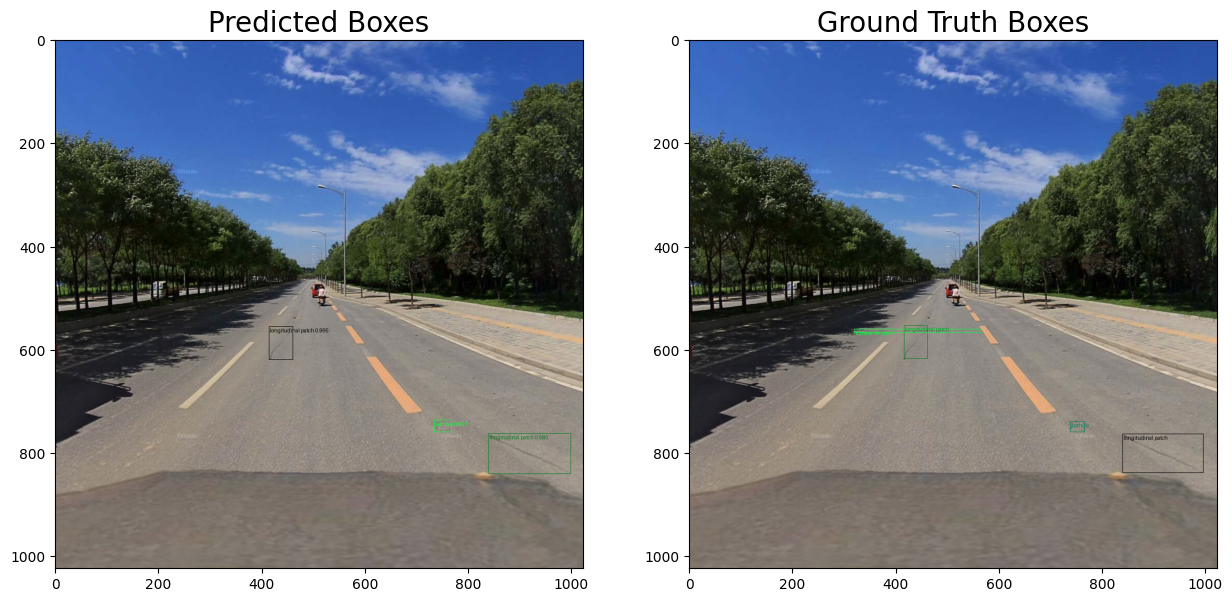

In [ ]:
# Example Prediction
image_id = 50
pred_box, pred_label, pred_score = get_one_example_prediction(image_id, results)

# Getting image and target from dataset
print("Predicting...")
img_tensor, target = eval_dataset[image_id]

# Adjust to best threshold
threshold = 0.5
keep = pred_score >= threshold
boxes = pred_box[keep]
labels = pred_label[keep]
scores = pred_score[keep]

# Convert boxes from COCO format [x, y, w, h] to xyxy [xmin, ymin, xmax, ymax]
boxes[:, 2] = boxes[:, 0] + boxes[:, 2]
boxes[:, 3] = boxes[:, 1] + boxes[:, 3]

print("Visualizing Prediction...")
# Visualize predictions.
image_with_boxes = utils.draw_bounding_boxes(
    image=(img_tensor * 255).to(torch.uint8),
    boxes=boxes,
    labels=[f"{CLASSES[label.item()]} {score:.3f}" for label, score in zip(labels, scores)],
)

fig, ax = plt.subplots(1, 2, figsize=(15, 15))
ax[0].imshow(image_with_boxes.permute(1, 2, 0))

print("Visualizing GroundTruth...")
# Visualize predictions.
image_with_boxes = utils.draw_bounding_boxes(
    image=(img_tensor * 255).to(torch.uint8),
    boxes=target["boxes"],
    labels=[f"{CLASSES[label.item()]}" for label in target["labels"]],
)

# Colocar título nas imagens
ax[0].set_title("Predicted Boxes", fontsize=20)
ax[1].set_title("Ground Truth Boxes", fontsize=20)
ax[1].imshow(image_with_boxes.permute(1, 2, 0))
fig.savefig("pred_ground_truth.png")
plt.show()

# YOLOv11